# B-0302C — AutoML FULL (test)

Task `363f8e27` (full, janelas 30/60). Melhor: LSTM/baseline/p99 → 30% detecção @ 0,87% FP —
modesto, porém acima do ~0% previsto pela triagem (LSTM capta mais que limiar simples). SAVE_PLOTS off.

In [1]:
import sys; from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from clearml import Task
PROJECT_ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'pyproject.toml').exists()),Path.cwd())
sys.path.insert(0,str(PROJECT_ROOT/'src'))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [2]:
EQUIPMENT_ID='B-0302C'; AUTOML_TASK_ID='363f8e277bb84cea970e7d388fb98249'
EVENT_TS_F1=pd.Timestamp('2024-08-30 00:00'); EVENT_LABEL_F1='Falha'
PREFAILURE_DAYS=30; NORMAL_END_DAYS=60
KEY_SENSORS=['Vibração Mancal Bomba LA', 'Pressão diferencial filtro']
SAVE_PLOTS=False

In [3]:
def load_scores(task_id):
    task=Task.get_task(task_id=task_id)
    s=task.artifacts['best_full_scores'].get(); s.index=pd.to_datetime(s.index); s=s.sort_index()
    s['is_anomaly']=s['is_anomaly'].astype(bool)
    res=task.artifacts['automl_results'].get() if 'automl_results' in task.artifacts else None
    bt=task.artifacts['best_trial'].get() if 'best_trial' in task.artifacts else None
    return s[['reconstruction_error','is_anomaly']],res,bt,task
def persistence_filter(flags,k,n):
    if k==1 and n==1: return flags.astype(bool)
    return (flags.astype(int).rolling(window=n,min_periods=n).sum()>=k).fillna(False).astype(bool)
def load_plot_base(eq):
    cfg=EQUIPMENT_CONFIGS[eq]; df_raw=load_equipment_data(eq,from_clearml=False)
    df_base,_,_=run_preprocessing(df_raw,cfg.pre_split_steps,fitted_scaler=None) if cfg.pre_split_steps else (df_raw,None,None)
    df_base=df_base.sort_index(); df_base.index=pd.to_datetime(df_base.index); return df_base,cfg
def model_info_str(bt):
    t=bt['trial']; r=bt['results']
    return (f"Modelo AutoML: {str(t.get('model')).upper()} / {t.get('preset')} / p{t.get('threshold_percentile')} / "
            f"debounce {t.get('debounce_consecutive')}  ·  pré-falha {r.get('prefailure_alert_rate',0):.0%} @ FP {r.get('normal_alert_rate',0):.1%}")
def _slug(t): return ''.join(c if c.isalnum() else '_' for c in str(t)).strip('_').lower()
def plot_separated(df_window,scores_window,sensors,threshold,k,n,event_ts,event_label,prefailure_days,
                   title_prefix,tag,threshold_label='Limiar',model_info='',shade=False,save=False,outdir=None,dpi=200):
    plt.style.use('seaborn-v0_8-whitegrid')
    flags=persistence_filter(scores_window['reconstruction_error']>threshold,k=k,n=n); anom_idx=scores_window.index[flags]
    for col in list(sensors)+['__score__']:
        fig,ax=plt.subplots(figsize=(14,3.2))
        if col=='__score__':
            y=scores_window['reconstruction_error']; ax.plot(y.index,y,color='purple',lw=0.9,alpha=0.6,label='Score')
            ax.axhline(threshold,color='red',ls='--',lw=1.2,label=threshold_label)
            if len(anom_idx): ax.scatter(anom_idx,y.reindex(anom_idx),s=28,color='red',zorder=4,label='Alerta')
            ax.set_ylabel('Score'); ttl='Score de Anomalia'
        else:
            if col not in df_window.columns: plt.close(fig); continue
            ax.plot(df_window.index,df_window[col],color='steelblue',lw=1.0,alpha=0.85,label=col)
            av=df_window[col].reindex(anom_idx).dropna()
            if not av.empty: ax.scatter(av.index,av.values,s=28,color='red',zorder=4,label='Anomalia')
            ax.set_ylabel(col,fontsize=9); ttl=col
        ax.axvline(event_ts,color='orange',ls='--',lw=1.4,label=event_label); ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8)
        ax.set_title(f'{title_prefix} | {ttl}',fontsize=12,fontweight='bold')
        if model_info: ax.text(0.5,1.10,model_info,transform=ax.transAxes,ha='center',fontsize=8,color='dimgray')
        fig.tight_layout(); plt.show()

In [4]:
scores,automl_results,bt,task=load_scores(AUTOML_TASK_ID); df_base,cfg=load_plot_base(EQUIPMENT_ID)
MODEL_INFO=model_info_str(bt); tr=bt['trial']; rs=bt['results']
print('Task:',task.name,'| status:',task.get_status(),'| trials:',len(automl_results))
print(MODEL_INFO)
print('scores:',scores.index.min(),'->',scores.index.max())

Task: automl-b0302c-test | status: completed | trials: 2121
Modelo AutoML: LSTM / baseline / p99.0 / debounce 1  ·  pré-falha 30% @ FP 0.9%
scores: 2024-02-01 05:55:00 -> 2024-09-10 00:00:00


## Ranking (top 10) — com FP held-out

In [5]:
cols=[x for x in ['model','preset','threshold_percentile','debounce_consecutive','prefailure_alert_rate','normal_alert_rate','val_fp_rate_heldout','composite_score'] if x in automl_results.columns]
fmt={k:'{:.2%}' for k in ['prefailure_alert_rate','normal_alert_rate','val_fp_rate_heldout']}; fmt['composite_score']='{:.4f}'; fmt['threshold_percentile']='{:.1f}'
sty=automl_results[cols].head(10).style.format({k:v for k,v in fmt.items() if k in cols})
if 'prefailure_alert_rate' in cols: sty=sty.background_gradient(subset=['prefailure_alert_rate'],cmap='Greens')
if 'val_fp_rate_heldout' in cols: sty=sty.background_gradient(subset=['val_fp_rate_heldout'],cmap='Reds_r')
display(sty)
if 'val_fp_rate_heldout' in automl_results.columns:
    print('Compare normal_alert_rate (in-sample) vs val_fp_rate_heldout (held-out, número honesto).')

,model,preset,threshold_percentile,debounce_consecutive,prefailure_alert_rate,normal_alert_rate,val_fp_rate_heldout,composite_score
0,lstm,baseline,99.0,1,30.24%,0.87%,18.88%,0.2998
1,lstm,baseline,99.0,6,24.95%,0.54%,18.13%,0.2482
2,lstm,baseline,99.0,6,22.41%,0.65%,17.01%,0.2226
3,ocsvm,baseline,97.5,4,22.01%,0.84%,17.13%,0.2183
4,ocsvm,baseline,97.5,4,21.82%,0.77%,16.72%,0.2165
5,lstm,baseline,99.0,6,21.74%,0.69%,16.01%,0.2159
6,ocsvm,baseline,97.5,4,21.60%,0.77%,16.53%,0.2143
7,ocsvm,baseline,97.5,6,21.56%,0.74%,16.66%,0.2140
8,ocsvm,baseline,97.5,6,21.42%,0.63%,16.32%,0.2129
9,ocsvm,baseline,97.5,4,21.35%,0.75%,16.06%,0.2119


Compare normal_alert_rate (in-sample) vs val_fp_rate_heldout (held-out, número honesto).


## Ajuste de sensibilidade

In [6]:
_e=scores['reconstruction_error']; _ne=EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS); _ps=EVENT_TS_F1-pd.Timedelta(days=PREFAILURE_DAYS)
_mn=scores.index<_ne; _mp=(scores.index>=_ps)&(scores.index<EVENT_TS_F1); _mpost=scores.index>=EVENT_TS_F1
def _deb(f,k,n): return (f.astype(int).rolling(n,min_periods=n).sum()>=k).fillna(False) if n>1 else f.astype(bool)
rows=[]
for p in [99.0,99.5,99.7,99.9]:
    thr=float(np.percentile(_e[_mn].values,p))
    for (k,n) in [(1,1),(4,6),(6,8)]:
        fl=_deb(_e>thr,k,n)
        rows.append({'percentil':p,'debounce':f'{k}/{n}','threshold':thr,'normal_FP':fl[_mn].mean(),'prefalha':fl[_mp].mean(),'pos':int(fl[_mpost].sum())})
g=pd.DataFrame(rows)
display(g.style.format({'threshold':'{:.5f}','normal_FP':'{:.2%}','prefalha':'{:.0%}'}).background_gradient(subset=['normal_FP'],cmap='Reds_r').background_gradient(subset=['prefalha'],cmap='Greens'))
TUNE_PERCENTILE=99.5; TUNE_K,TUNE_N=6,8
selected_threshold=float(np.percentile(_e[_mn].values,TUNE_PERCENTILE)); selected_k,selected_n=TUNE_K,TUNE_N
threshold_label=f'Limiar p{TUNE_PERCENTILE}+deb{TUNE_K}/{TUNE_N}'; flags=persistence_filter(_e>selected_threshold,selected_k,selected_n)
print(f'{threshold_label}: prefalha={flags[_mp].mean():.0%} normal_FP={flags[_mn].mean():.2%} (alertas começo da série/normal={int(flags[_mn].sum())})')

,percentil,debounce,threshold,normal_FP,prefalha,pos
0,99.000000,1/1,0.01900,1.00%,20%,63
1,99.000000,4/6,0.01900,0.88%,19%,62
2,99.000000,6/8,0.01900,0.76%,19%,60
3,99.500000,1/1,0.02257,0.50%,17%,55
4,99.500000,4/6,0.02257,0.46%,17%,56
5,99.500000,6/8,0.02257,0.42%,17%,54
6,99.700000,1/1,0.02851,0.30%,15%,11
7,99.700000,4/6,0.02851,0.28%,15%,9
8,99.700000,6/8,0.02851,0.25%,15%,4
9,99.900000,1/1,0.03392,0.10%,15%,0


Limiar p99.5+deb6/8: prefalha=17% normal_FP=0.42% (alertas começo da série/normal=182)


## Zoom antes da falha (com score; modelo no topo)

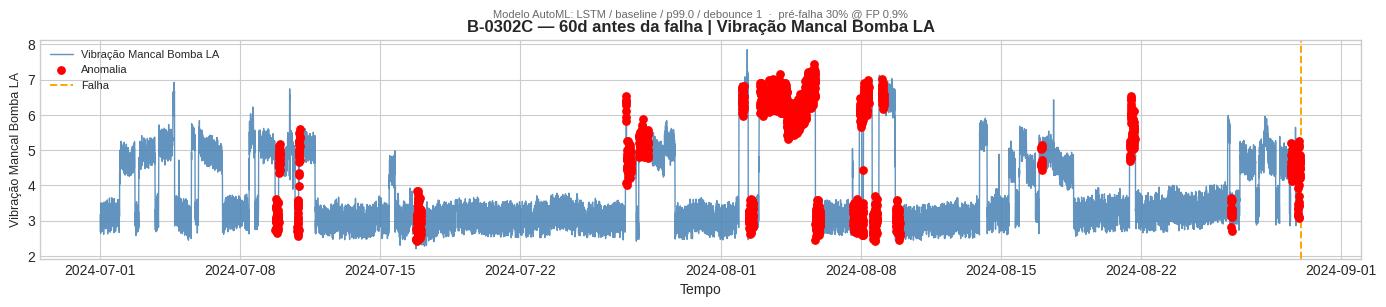

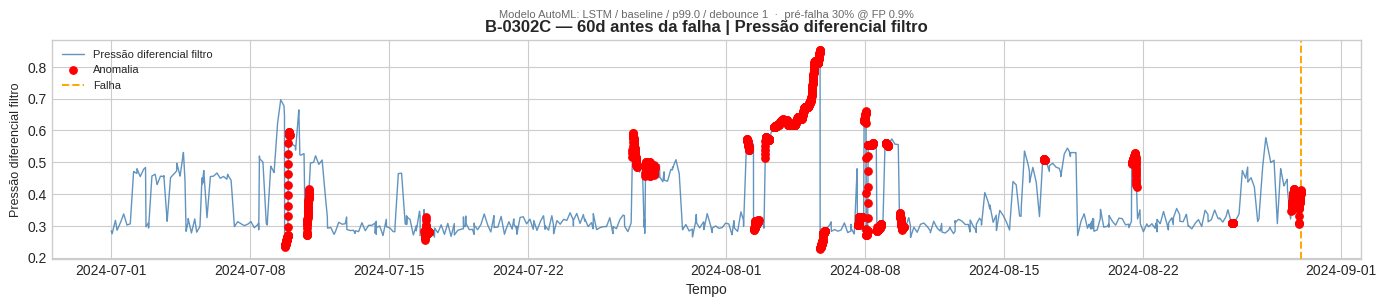

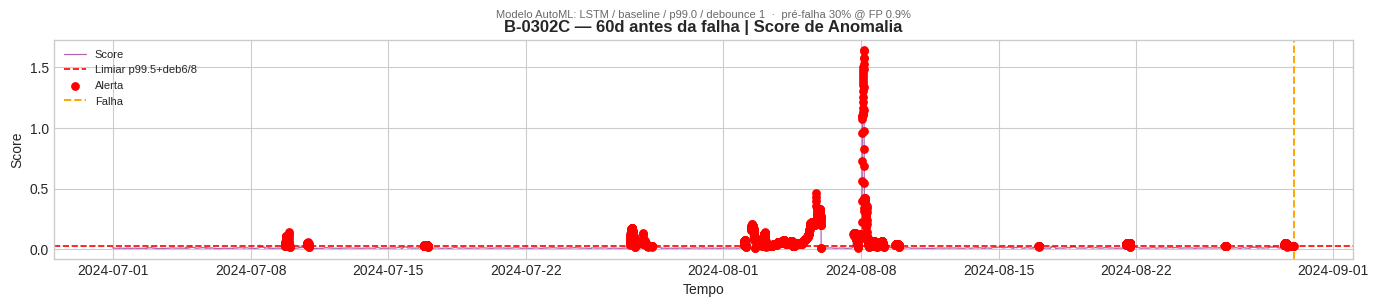

In [7]:
z=EVENT_TS_F1-pd.Timedelta(days=60); dfw=df_base.loc[z:EVENT_TS_F1]; sw=scores.loc[z:EVENT_TS_F1]
common=dfw.index.intersection(sw.index); dfw,sw=dfw.loc[common],sw.loc[common]
sensors=[s for s in KEY_SENSORS if s in dfw.columns]
plot_separated(dfw,sw,sensors,selected_threshold,selected_k,selected_n,EVENT_TS_F1,EVENT_LABEL_F1,PREFAILURE_DAYS,
   title_prefix=f'{EQUIPMENT_ID} — 60d antes da falha',tag='zoom',threshold_label=threshold_label,model_info=MODEL_INFO)

## Série completa

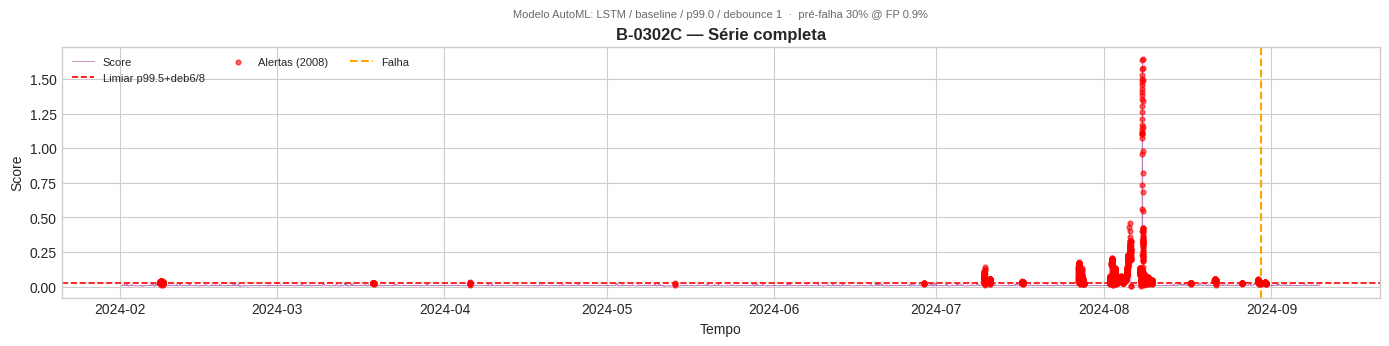

alertas no começo (normal,<-60d): 182


In [8]:
plt.style.use('seaborn-v0_8-whitegrid'); fig,ax=plt.subplots(figsize=(14,3.6)); y=_e
fl=persistence_filter(y>selected_threshold,selected_k,selected_n)
ax.plot(scores.index,y,color='purple',lw=0.6,alpha=0.5,label='Score'); ax.axhline(selected_threshold,color='red',ls='--',lw=1.2,label=threshold_label)
idx=scores.index[fl]; ax.scatter(idx,y[idx],s=12,color='red',alpha=0.6,zorder=4,label=f'Alertas ({len(idx)})')
ax.axvline(EVENT_TS_F1,color='orange',ls='--',lw=1.5,label=EVENT_LABEL_F1)
ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8,ncol=3)
ax.set_title(f'{EQUIPMENT_ID} — Série completa',fontweight='bold'); ax.text(0.5,1.12,MODEL_INFO,transform=ax.transAxes,ha='center',fontsize=8,color='dimgray')
fig.tight_layout(); plt.show(); print(f'alertas no começo (normal,<-{NORMAL_END_DAYS}d): {int(fl[_mn].sum())}')